<a href="https://colab.research.google.com/github/amitdey7/MS107/blob/master/Pytorch_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

x = torch.tensor([3.0, 3.0, 6])

print(torch.softmax(x, dim=-1))

tensor([0.0453, 0.0453, 0.9094])


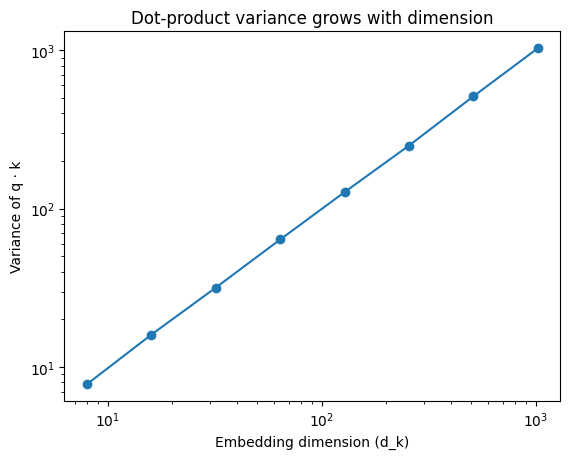

In [ ]:
# scaling by root of dimension
import matplotlib.pyplot as plt

torch.manual_seed(0)

dims = [8, 16, 32, 64, 128, 256, 512, 1024]
variances = []

num_samples = 10_000

for d in dims:
    q = torch.randn(num_samples, d)
    k = torch.randn(num_samples, d)

    dots = (q * k).sum(dim=1)
    variances.append(dots.var().item())

plt.figure()
plt.plot(dims, variances, marker='o')
plt.xlabel("Embedding dimension (d_k)")
plt.ylabel("Variance of q · k")
plt.title("Dot-product variance grows with dimension")
plt.xscale("log")
plt.yscale("log")
plt.show()


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

def show_softmax(scores, label):
    probs = F.softmax(scores, dim=0)
    entropy = -(probs * torch.log(probs + 1e-9)).sum().item()
    print(label)
    print(f"  max prob : {probs.max().item():.4f}")
    print()
    return probs


In [ ]:
d = 10
num_keys = 10

Q = torch.randn(d)                  # query
K = torch.randn(num_keys, d)        # keys

scores = Q @ K.T                    # dot products

print("=== d = 10 ===")
probs_unscaled_10 = show_softmax(scores, "Softmax(Q·Kᵀ) — unscaled")
probs_scaled_10 = show_softmax(scores / (d ** 0.5), "Softmax(Q·Kᵀ / √d) — scaled")


=== d = 10 ===
Softmax(Q·Kᵀ) — unscaled
  max prob : 0.4869

Softmax(Q·Kᵀ / √d) — scaled
  max prob : 0.2106



In [ ]:
d = 100
num_keys = 10

Q = torch.randn(d)
K = torch.randn(num_keys, d)

scores = Q @ K.T

print("=== d = 100 ===")
probs_unscaled_100 = show_softmax(scores, "Softmax(Q·Kᵀ) — unscaled")
probs_scaled_100 = show_softmax(scores / (d ** 0.5), "Softmax(Q·Kᵀ / √d) — scaled")


=== d = 100 ===
Softmax(Q·Kᵀ) — unscaled
  max prob : 0.8676

Softmax(Q·Kᵀ / √d) — scaled
  max prob : 0.2550



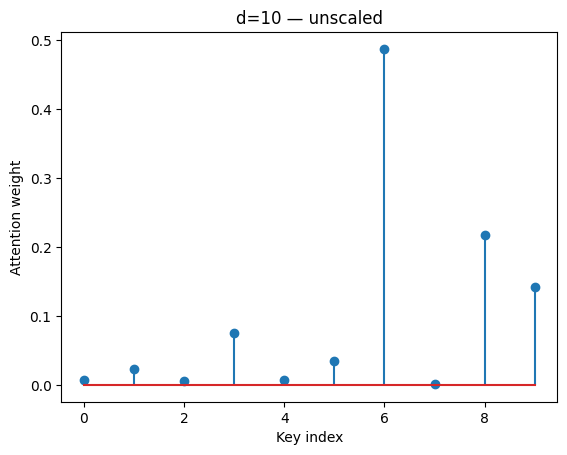

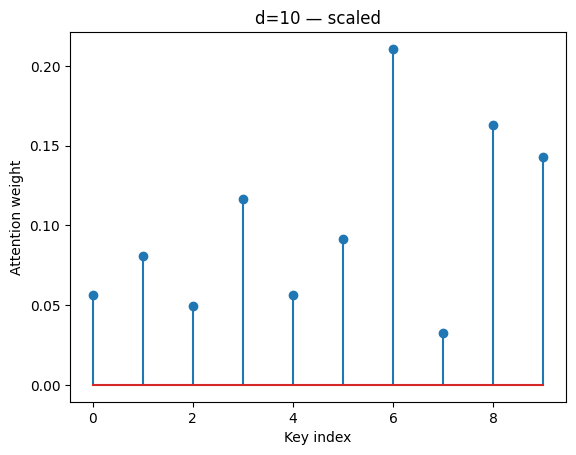

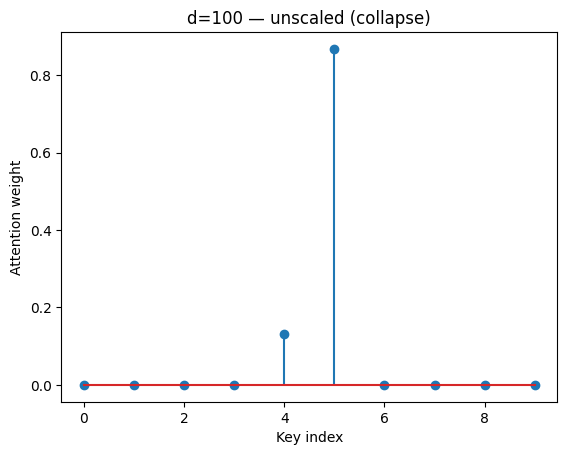

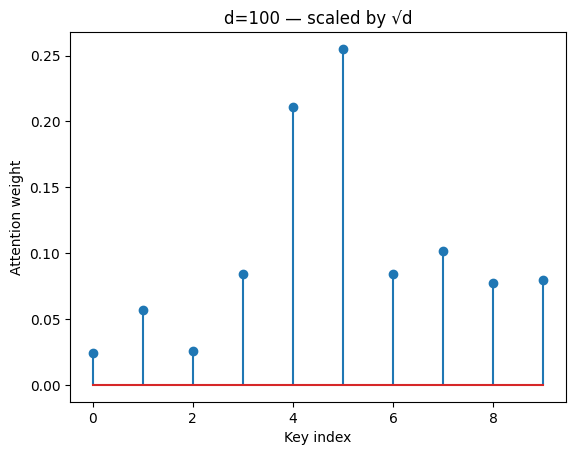

In [ ]:
def plot_probs(probs, title):
    plt.figure()
    plt.stem(probs.numpy())
    plt.title(title)
    plt.xlabel("Key index")
    plt.ylabel("Attention weight")
    plt.show()

plot_probs(probs_unscaled_10, "d=10 — unscaled")
plot_probs(probs_scaled_10, "d=10 — scaled")
plot_probs(probs_unscaled_100, "d=100 — unscaled (collapse)")
plot_probs(probs_scaled_100, "d=100 — scaled by √d")


### Layer Normalization

In [ ]:
import torch

# experiment settings
d = 5
nlayers = 100
normalize = False # set True to use normalization

# create vector with random entries between [-1, 1]
input_vector = (torch.rand(d) - 0.5) * 2.0

# create matrix with random entries between [-1, 1]
# by which we can repeatedly multiply the input vector
weight_matrix = (torch.rand(d, d) - 0.5) * 2.0

output = input_vector
for i in range(nlayers):
    # optionally perform normalization
    if normalize:
        output = (output - torch.mean(output)) / torch.std(output)

    # repeatedly multiply the vector by the matrix
    output = weight_matrix @ output

# observe output values
print(output)

tensor([ 5.5097e+16, -1.0194e+16, -1.0792e+17,  6.8143e+16, -2.4264e+16])
